In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv(r'.\Dataset\btcusd_1-min_data.csv')

In [17]:
# Which date has the highest closing price?
highest_close_date = df.loc[df['Close'].idxmax(), 'Timestamp']
highest_close_date = pd.to_datetime(highest_close_date, unit='s').date()
print(f"The date with the highest closing price is: {highest_close_date}")

The date with the highest closing price is: 2025-07-14


In [ ]:
# Convert 'Timestamp' to datetime and set as index
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df.set_index('Timestamp', inplace=True)
df = df.sort_index()
df.tail() 

,Open,High,Low,Close,Volume
Timestamp,,,,,
2025-07-27 05:54:00,118285.0,118289.0,118285.0,118288.0,0.011876
2025-07-27 05:55:00,118296.0,118299.0,118295.0,118299.0,0.097239
2025-07-27 05:56:00,118300.0,118322.0,118300.0,118322.0,0.081334
2025-07-27 05:57:00,118323.0,118335.0,118320.0,118335.0,0.259695
2025-07-27 05:58:00,118334.0,118335.0,118334.0,118335.0,0.221029


In [5]:
# Resampling to daily, monthly, yearly, and querterly frequency
df_daily = df.resample('D').mean()
df_monthly = df.resample('ME').mean()
df_yearly = df.resample('YE-DEC').mean() # Resampling the year to December end
df_quarterly = df.resample('QE-DEC').mean() # Resampling to quarterly frequency with December as the end of the quarter

Average Price / Typical Price: It smooths the volatility and better represents the market behavior.

In [ ]:
# Compute the Average price
df['Average_Price'] = (df['Open'] + df['High'] + df['Low'] + df['Close']) / 4

In [22]:
# Compute VWAP and Resample
VWP = df['Volume'] * df['Average_Price']
# Resample VWAP to daily, monthly, yearly, and quarterly frequency
vwap_minutely = VWP.resample('min').sum() / df['Volume'].resample('min').sum()
vwap_daily = VWP.resample('D').sum()/ df['Volume'].resample('D').sum()
vwap_monthly = VWP.resample('ME').sum()/ df['Volume'].resample('ME').sum()
vwap_yearly = VWP.resample('YE-DEC').sum()/ df['Volume'].resample('YE-DEC').sum()
vwap_quarterly = VWP.resample('QE-DEC').sum()/ df['Volume'].resample('QE-DEC').sum()

df_minute = vwap_minutely.to_frame(name='Weighted_Price')
df_daily = vwap_daily.to_frame(name='Weighted_Price')
df_monthly = vwap_monthly.to_frame(name='Weighted_Price')
df_yearly = vwap_yearly.to_frame(name='Weighted_Price')
df_quarterly = vwap_quarterly.to_frame(name='Weighted_Price')

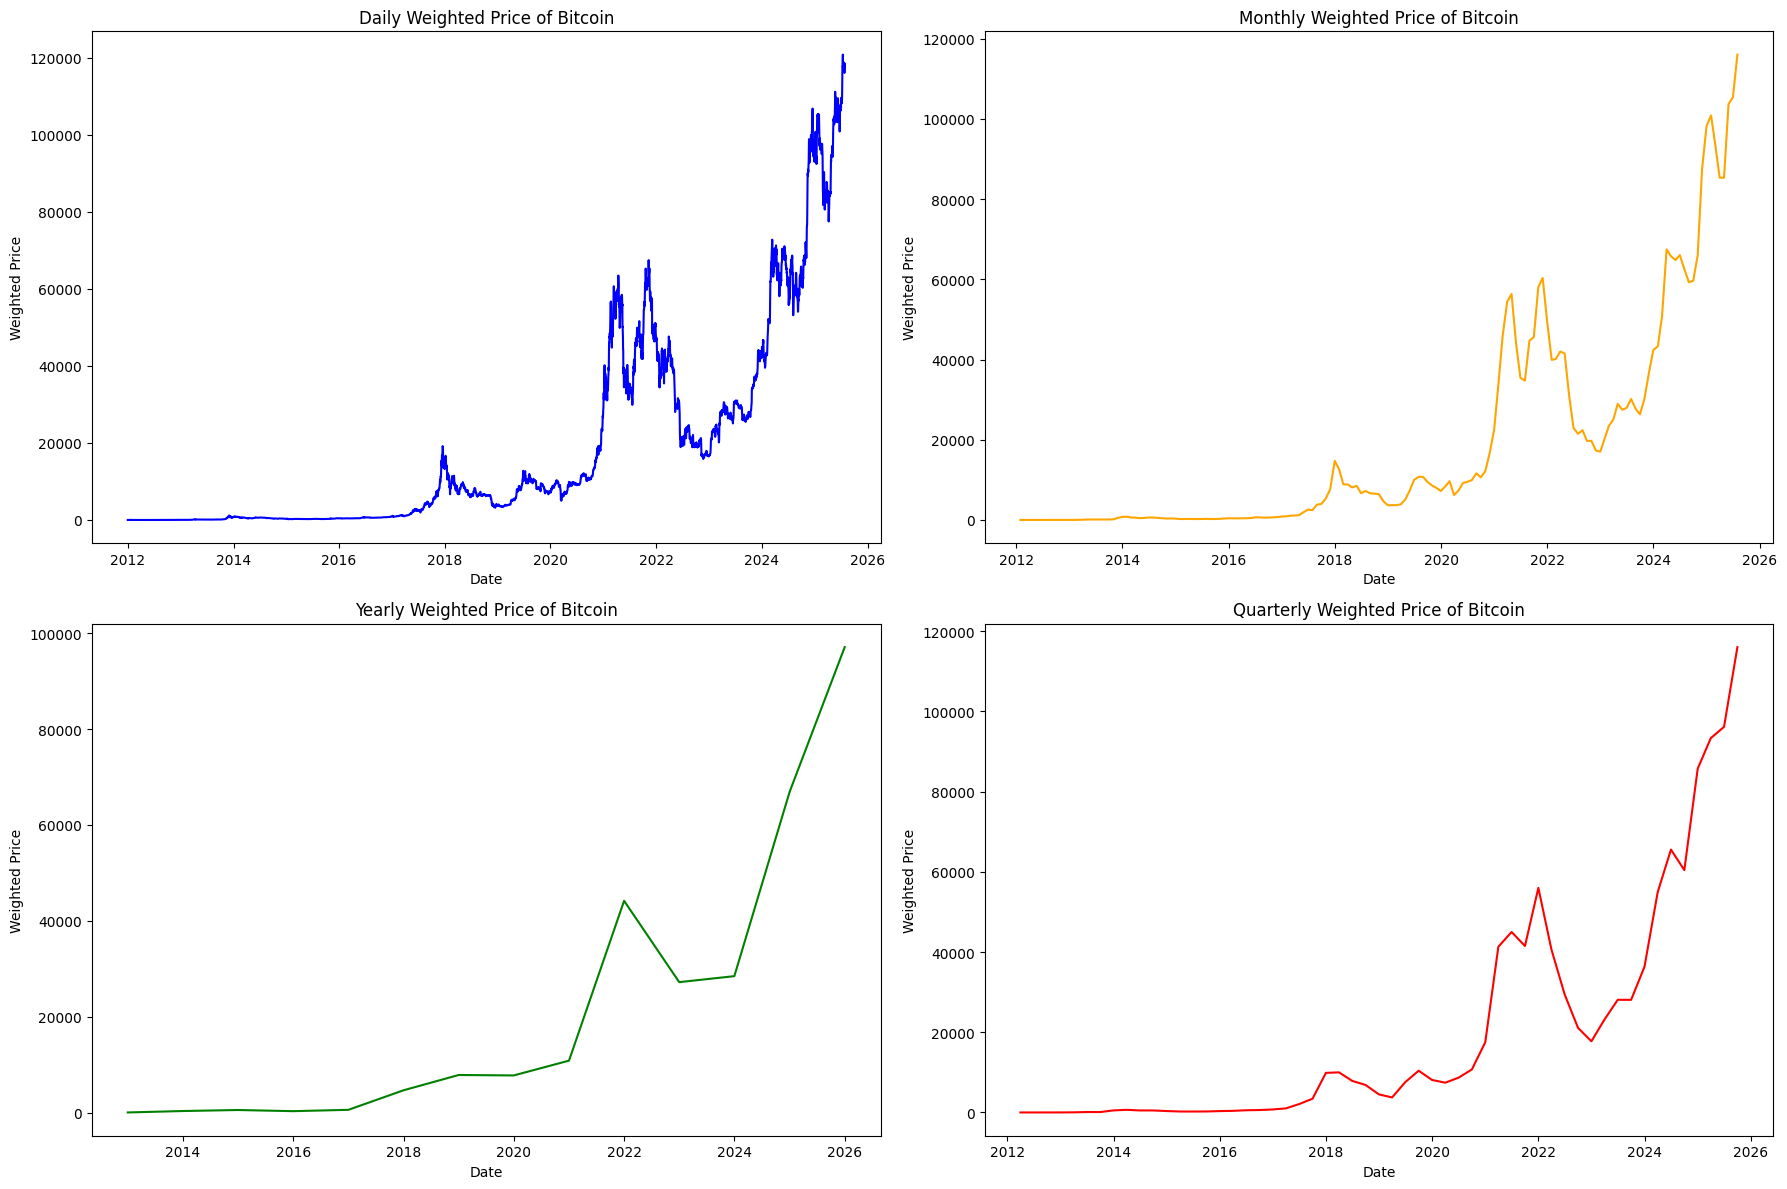

In [26]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(18, 12))

# Daily
axs[0, 0].plot(df_daily.index, df_daily['Weighted_Price'], color='blue')
axs[0, 0].set_title('Daily Weighted Price of Bitcoin')
axs[0, 0].set_xlabel('Date')
axs[0, 0].set_ylabel('Weighted Price')

# Monthly
axs[0, 1].plot(df_monthly.index, df_monthly['Weighted_Price'], color='orange')
axs[0, 1].set_title('Monthly Weighted Price of Bitcoin')
axs[0, 1].set_xlabel('Date')
axs[0, 1].set_ylabel('Weighted Price')

# Yearly
axs[1, 0].plot(df_yearly.index, df_yearly['Weighted_Price'], color='green')
axs[1, 0].set_title('Yearly Weighted Price of Bitcoin')
axs[1, 0].set_xlabel('Date')
axs[1, 0].set_ylabel('Weighted Price')

# Quarterly
axs[1, 1].plot(df_quarterly.index, df_quarterly['Weighted_Price'], color='red')
axs[1, 1].set_title('Quarterly Weighted Price of Bitcoin')
axs[1, 1].set_xlabel('Date')
axs[1, 1].set_ylabel('Weighted Price')

plt.tight_layout()
plt.show()
